# Benchmark 3: leader failover recovery time
Wall-clock time from `kill -9` on the leader to the first successful write afterwards. Run `bench/03-failover-recovery.sh` first.

In [ ]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
from plot_style import load, agg


In [ ]:
df = load("failover-recovery.csv")
df

,run,clusterSize,recoveryMs
0,1,3,1102.0
1,2,3,492.7
2,3,3,740.6
3,4,3,489.0
4,5,3,378.3
5,6,3,492.6
6,7,3,868.5
7,8,3,491.2
8,9,3,259.7
9,10,3,1094.7


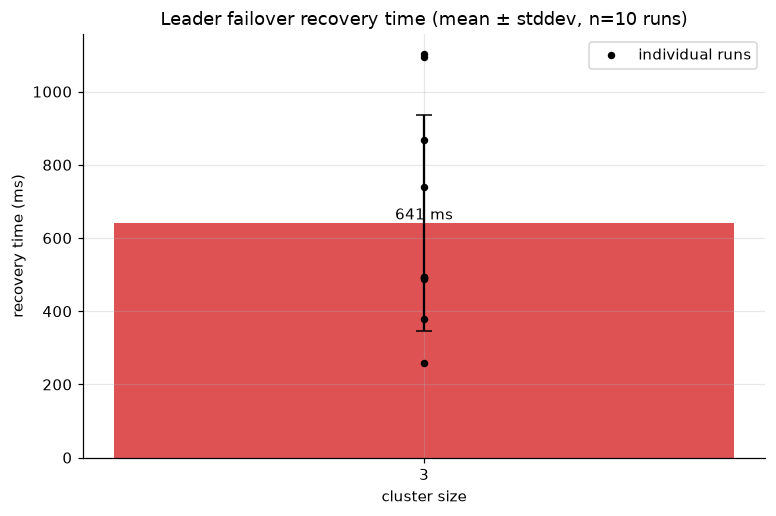

In [ ]:
summary = agg(df, ["clusterSize"], "recoveryMs")

fig, ax = plt.subplots()
x = range(len(summary))
ax.bar(x, summary["mean"], yerr=summary["std"], capsize=5, color="tab:red", alpha=0.8)
for i, size in enumerate(summary["clusterSize"]):
    runs = df.loc[df["clusterSize"] == size, "recoveryMs"]
    ax.scatter([i] * len(runs), runs, color="black", zorder=3, s=15, label="individual runs" if i == 0 else None)
ax.set_xticks(list(x), summary["clusterSize"].astype(str))
ax.set_xlabel("cluster size")
ax.set_ylabel("recovery time (ms)")
ax.set_title(f"Leader failover recovery time (mean ± stddev, n={summary['count'].iloc[0]} runs)")
for i, v in enumerate(summary["mean"]):
    ax.text(i, v, f"{v:.0f} ms", ha="center", va="bottom")
ax.legend()
plt.show()